## Final Project Submission

Please fill out:
* Student name: 
* Student pace: self paced / part time / full time
* Scheduled project review date/time: 
* Instructor name: 
* Blog post URL:


In [108]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3 

In [109]:
conn = sqlite3.connect('zippedData/im.db')

In [110]:
cur = conn.cursor()

In [111]:
df = pd.read_csv("zippedData/bom.movie_gross.csv.gz")

# **Data Understanding**
- For our analysis, the two most relevant data files we used are:
    - im.db, specifically the movie_basics and movie_ratings tables
    - bom.movie_gross.csv.gz 

### Bom.movie csv 

In [112]:
df.shape

(3387, 5)

In [113]:
df.dtypes

title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

In [114]:
df.describe()

,domestic_gross,year
count,3.359000e+03,3387.000000
mean,2.874585e+07,2013.958075
std,6.698250e+07,2.478141
min,1.000000e+02,2010.000000
25%,1.200000e+05,2012.000000
50%,1.400000e+06,2014.000000
75%,2.790000e+07,2016.000000
max,9.367000e+08,2018.000000


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


- studio has missing data 
- domestic gross has missing data 
- foreign gross has missing data 
- foreign gross should be float not object 
- year data to be datetime 


In [116]:
df.isna().sum()

title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

In [117]:
# Missing values %
def missing(df,col):
    missing = (df[col].isna().sum()/len(df))*100
    if missing == 0:
        print(f" we have {missing} % missing from {col}")
    elif missing < 5:
        print(f" we have {missing} % missing from {col} we can go ahead and either drop the rows or fill in the missing values")
    elif missing < 30:
        print(f" we have {missing} % missing from {col} we can go ahead and fill in the missing values")
    else :
        print(f" we have {missing} % missing from {col} we can go ahead and drop the column or consider other alternatives")

In [118]:
missing(df,'studio')

 we have 0.14762326542663123 % missing from studio we can go ahead and either drop the rows or fill in the missing values


In [119]:
missing(df,'domestic_gross')

 we have 0.8266902863891349 % missing from domestic_gross we can go ahead and either drop the rows or fill in the missing values


In [120]:
missing(df, 'foreign_gross')

 we have 39.85828166519043 % missing from foreign_gross we can go ahead and drop the column or consider other alternatives


In [121]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [122]:
df.tail()

,title,studio,domestic_gross,foreign_gross,year
3382,The Quake,Magn.,6200.0,NaN,2018
3383,Edward II (2018 re-release),FM,4800.0,NaN,2018
3384,El Pacto,Sony,2500.0,NaN,2018
3385,The Swan,Synergetic,2400.0,NaN,2018
3386,An Actor Prepares,Grav.,1700.0,NaN,2018


### Movie Data ERD 
![alt text](movie_data_erd.jpeg)


In [123]:
# im.db movie_basics 
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [124]:
# im.db movie_ratings

query_2 = pd.read_sql("""
SELECT * FROM movie_ratings 
LIMIT 5;
""", conn)

query_2

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


# **Data Cleaning**

As we saw in our above inspection the following cleaning tasks were to be completed to have a clean data set ready for analysis
1. Bom.movie csv 
    - foreign gross d type needs to be changed from object to float 
    - studio has 0.14% missing data - we can drop those rows 
    - domestic gross has 0.82% if missing data - we can drop those rows 

In [125]:
df['foreign_gross'].unique()

array(['652000000', '691300000', '664300000', ..., '530000', '256000',
       '30000'], dtype=object)

In [126]:
# change foreign gross d type 
df['foreign_gross'] = df['foreign_gross'].str.replace(',', '').astype('float')


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   float64
 4   year            3387 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 132.4+ KB


In [128]:
df = df.dropna(subset=['studio'])

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3382 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3382 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2033 non-null   float64
 4   year            3382 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 158.5+ KB


In [130]:
# Dropping if any rows where BOTH domestic_gross and foreign_gross are missing 
# Without either it is difficult to do any meaningful analysis 
df = df.dropna(subset=['domestic_gross','foreign_gross'], how='all')

In [131]:
# seems that no such entry exists where both foreign or domestic gross is missing
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3382 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3382 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2033 non-null   float64
 4   year            3382 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 158.5+ KB


In [132]:
df.isna().sum()
# since there is 26 missing values in the domestic gross column
# best option is to drop these missing value rows 

title                0
studio               0
domestic_gross      26
foreign_gross     1349
year                 0
dtype: int64

In [133]:
df = df.dropna(subset=['domestic_gross'])

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3356 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3356 non-null   object 
 1   studio          3356 non-null   object 
 2   domestic_gross  3356 non-null   float64
 3   foreign_gross   2007 non-null   float64
 4   year            3356 non-null   int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 157.3+ KB


In [135]:
df.describe()

,domestic_gross,foreign_gross,year
count,3.356000e+03,2.007000e+03,3356.000000
mean,2.877149e+07,7.579038e+07,2013.970203
std,6.700694e+07,1.381796e+08,2.479064
min,1.000000e+02,6.000000e+02,2010.000000
25%,1.200000e+05,3.900000e+06,2012.000000
50%,1.400000e+06,1.940000e+07,2014.000000
75%,2.795000e+07,7.595000e+07,2016.000000
max,9.367000e+08,9.605000e+08,2018.000000


In [136]:
df[df.duplicated(subset=['title'])]

,title,studio,domestic_gross,foreign_gross,year
3045,Bluebeard,WGUSA,43100.0,NaN,2017


<AxesSubplot:xlabel='domestic_gross'>

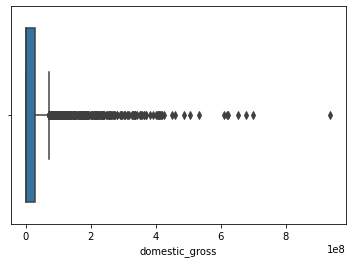

In [137]:
sns.boxplot(x=df['domestic_gross'])

<AxesSubplot:xlabel='domestic_gross', ylabel='Count'>

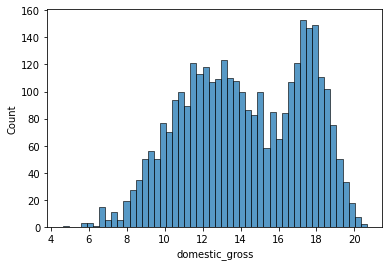

In [138]:
sns.histplot(np.log1p(df['domestic_gross']), bins=50)

In [139]:
Q1 = df['domestic_gross'].quantile(0.25)
Q3 = df['domestic_gross'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['domestic_gross'] < lower) | (df['domestic_gross'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 406


In [140]:
Q1 = df['foreign_gross'].quantile(0.25)
Q3 = df['foreign_gross'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['foreign_gross'] < lower) | (df['foreign_gross'] > upper)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 256


**Note**: Although domestic gross and foreign gross both have outliers in our dataset we made the decision to retain them. This is because financial data like box office gross is meaningful data and is quite realistic

2. Movie ERD

In [141]:
query = pd.read_sql("""
SELECT name FROM sqlite_master WHERE type='table';
""", conn)
query

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [142]:
movie_basics = pd.read_sql("""SELECT * FROM movie_basics;""", conn)
movie_basics.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

In [143]:
movie_ratings = pd.read_sql("""
SELECT * FROM movie_ratings;""", conn)
movie_basics.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

# **Exploratory Data Analysis**

1. Which genres deliver the best financial returns? 
    - In order to explore this Business Q, the movie_basics table needs to be merged with the bom.movie csv 
    - Additionally, a new column called "primary_genre" must be feature engineered for genre analysis to work

In [144]:
df.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000.0,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000.0,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000.0,2010
3,Inception,WB,292600000.0,535700000.0,2010
4,Shrek Forever After,P/DW,238700000.0,513900000.0,2010


In [145]:
query = pd.read_sql(""" 
SELECT * FROM movie_basics 
LIMIT 5;
""", conn)

query

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [146]:
# merge both tables 

movie_basics_df = pd.read_sql("""
SELECT * FROM movie_basics;""", conn)

In [147]:
merged_df = pd.merge(
    movie_basics_df, 
    df,
    left_on='primary_title',
    right_on='title',
    how="inner")

In [148]:
merged_df.head(20)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,studio,domestic_gross,foreign_gross,year
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",Wazir,Relbig.,1100000.0,NaN,2016
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",On the Road,IFC,744000.0,8000000.0,2012
2,tt2404548,On the Road,On the Road,2011,90.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
3,tt3872966,On the Road,On the Road,2013,87.0,Documentary,On the Road,IFC,744000.0,8000000.0,2012
4,tt4339118,On the Road,On the Road,2014,89.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
5,tt5389486,On the Road,On the Road,2015,39.0,Documentary,On the Road,IFC,744000.0,8000000.0,2012
6,tt5647250,On the Road,On the Road,2016,121.0,Drama,On the Road,IFC,744000.0,8000000.0,2012
7,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",The Secret Life of Walter Mitty,Fox,58200000.0,129900000.0,2013
8,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",A Walk Among the Tombstones,Uni.,26300000.0,26900000.0,2014
9,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",Jurassic World,Uni.,652300000.0,1019.4,2015


In [149]:
merged_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,studio,domestic_gross,foreign_gross,year
3336,tt8404272,How Long Will I Love U,Chao shi kong tong ju,2018,101.0,Romance,How Long Will I Love U,WGUSA,747000.0,82100000.0,2018
3337,tt8427036,Helicopter Eela,Helicopter Eela,2018,135.0,Drama,Helicopter Eela,Eros,72000.0,NaN,2018
3338,tt8851262,Spring Fever,Spring Fever,2019,NaN,"Comedy,Horror",Spring Fever,Strand,10800.0,150000.0,2010
3339,tt9078374,Last Letter,"Ni hao, Zhihua",2018,114.0,"Drama,Romance",Last Letter,CL,181000.0,NaN,2018
3340,tt9151704,Burn the Stage: The Movie,Burn the Stage: The Movie,2018,84.0,"Documentary,Music",Burn the Stage: The Movie,Trafalgar,4200000.0,16100000.0,2018


In [150]:
merged_df.duplicated().sum()

0

In [151]:
merge = pd.merge(movie_basics_df, df[['title','domestic_gross', 'foreign_gross']],
                 left_on='primary_title',
                 right_on='title',
                 how="inner")

merge.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,title,domestic_gross,foreign_gross
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",Wazir,1100000.0,NaN
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",On the Road,744000.0,8000000.0
2,tt2404548,On the Road,On the Road,2011,90.0,Drama,On the Road,744000.0,8000000.0
3,tt3872966,On the Road,On the Road,2013,87.0,Documentary,On the Road,744000.0,8000000.0
4,tt4339118,On the Road,On the Road,2014,89.0,Drama,On the Road,744000.0,8000000.0


In [152]:
merge.isna().sum()

movie_id              0
primary_title         0
original_title        0
start_year            0
runtime_minutes     167
genres               40
title                 0
domestic_gross        0
foreign_gross      1322
dtype: int64

Note - ran into unexpected duplication and Nan values when merging. Next strategy employed is to change the column_name in the csv to match the column name on the movie_basics table to merge easily

In [153]:
df_q_1 = df.rename(columns={'title': 'primary_title', 'year': 'start_year'})

merge_1 = pd.merge(movie_basics_df, 
                    df_q_1[['primary_title', 'start_year', 'domestic_gross', 'foreign_gross']],
                    on=['primary_title', 'start_year'],
                    how="inner")


In [154]:
merge_1.head(20)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,domestic_gross,foreign_gross
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",1100000.0,NaN
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",744000.0,8000000.0
2,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",58200000.0,129900000.0
3,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",26300000.0,26900000.0
4,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",652300000.0,1019.4
5,tt0376136,The Rum Diary,The Rum Diary,2011,119.0,"Comedy,Drama",13100000.0,10800000.0
6,tt0376479,American Pastoral,American Pastoral,2016,108.0,"Crime,Drama",544000.0,NaN
7,tt0383010,The Three Stooges,The Three Stooges,2012,92.0,"Comedy,Family",44300000.0,10500000.0
8,tt0398286,Tangled,Tangled,2010,100.0,"Adventure,Animation,Comedy",200800000.0,391000000.0
9,tt0401729,John Carter,John Carter,2012,132.0,"Action,Adventure,Sci-Fi",73100000.0,211100000.0


In [155]:
merge_1.isna().sum()

movie_id             0
primary_title        0
original_title       0
start_year           0
runtime_minutes     10
genres               2
domestic_gross       0
foreign_gross      595
dtype: int64

In [156]:
merge_1['primary_title'].value_counts().head(30)

The Wall                   3
They Shall Not Grow Old    2
The Negotiation            2
The Bounty Hunter          2
Spotlight                  2
Coco                       2
I'm Still Here             2
The Forest                 2
Big Eyes                   2
Cyrus                      2
The Guardians              2
Sleepless                  2
Homefront                  2
The Darkness               2
Truth or Dare              2
Abduction                  2
Addicted                   2
The Call                   2
Jai Ho                     2
Stronger                   2
The Walk                   2
The Artist                 2
Dancer                     2
Burlesque                  2
Leap Year                  2
Gone                       2
True Story                 2
The Bay                    2
The Journey                2
Lights Out                 2
Name: primary_title, dtype: int64

In [157]:
print(len(movie_basics_df), len(merge_1))

146144 1863


In [158]:
print(len(df))

3356


In [178]:
merge_1['primary_genre'] = merge_1['genres'].str.split(',').str[0]

In [179]:
merge_1.dtypes

movie_id            object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
domestic_gross       int64
foreign_gross      float64
primary_genre       object
dtype: object

In [180]:
merge_1.head(10)

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,domestic_gross,foreign_gross,primary_genre
0,tt0315642,Wazir,Wazir,2016,103.0,"Action,Crime,Drama",1100000,NaN,Action
1,tt0337692,On the Road,On the Road,2012,124.0,"Adventure,Drama,Romance",744000,8000000.0,Adventure
2,tt0359950,The Secret Life of Walter Mitty,The Secret Life of Walter Mitty,2013,114.0,"Adventure,Comedy,Drama",58200000,129900000.0,Adventure
3,tt0365907,A Walk Among the Tombstones,A Walk Among the Tombstones,2014,114.0,"Action,Crime,Drama",26300000,26900000.0,Action
4,tt0369610,Jurassic World,Jurassic World,2015,124.0,"Action,Adventure,Sci-Fi",652300000,1019.4,Action
5,tt0376136,The Rum Diary,The Rum Diary,2011,119.0,"Comedy,Drama",13100000,10800000.0,Comedy
6,tt0376479,American Pastoral,American Pastoral,2016,108.0,"Crime,Drama",544000,NaN,Crime
7,tt0383010,The Three Stooges,The Three Stooges,2012,92.0,"Comedy,Family",44300000,10500000.0,Comedy
8,tt0398286,Tangled,Tangled,2010,100.0,"Adventure,Animation,Comedy",200800000,391000000.0,Adventure
9,tt0401729,John Carter,John Carter,2012,132.0,"Action,Adventure,Sci-Fi",73100000,211100000.0,Action


In [181]:
merge_1['primary_genre'].value_counts()

Action         521
Comedy         396
Drama          333
Biography      168
Adventure      166
Documentary     81
Crime           79
Horror          67
Animation       18
Fantasy          9
Thriller         8
Romance          7
Mystery          5
Music            2
Sci-Fi           1
Name: primary_genre, dtype: int64

In [182]:
financial = merge_1.groupby('primary_genre')['domestic_gross'].mean().sort_values(ascending=False)

financial 

primary_genre
Adventure      8.962618e+07
Action         6.965484e+07
Mystery        6.705660e+07
Animation      5.006581e+07
Horror         3.969576e+07
Comedy         2.742875e+07
Biography      2.635948e+07
Crime          2.099816e+07
Drama          1.840538e+07
Romance        9.264714e+06
Thriller       6.950650e+06
Documentary    6.702051e+06
Fantasy        4.544667e+06
Music          1.836000e+06
Sci-Fi         7.800000e+04
Name: domestic_gross, dtype: float64